# JIT vs Interpret Heuristic Model

Trains a classifier (Random Forest / Decision Tree) to predict the best execution mode
(JIT or interpreter) for each function in a WebAssembly binary, using profiling data
from all workloads of a benchmark. Generates `heuristics.json` plans.

In [2]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

REPO_ROOT = Path('../../').resolve()
print('Repo root:', REPO_ROOT)

Repo root: /users/khordadi/truejit


## Path utilities

In [3]:
def profiles_root(benchmark_name, workload=None):
    root = REPO_ROOT / 'profiles' / benchmark_name
    if workload is not None:
        root = root / workload
    return root


def plans_root(benchmark_name):
    root = REPO_ROOT / 'plans' / benchmark_name
    root.mkdir(parents=True, exist_ok=True)
    return root


def get_workloads(benchmark_name):
    return sorted(
        d.name for d in profiles_root(benchmark_name).iterdir()
        if d.is_dir() and (d / 'profile.csv').exists()
    )

## Data loading

For each workload, load `profile.csv` and compute:
- `cost.interp = exec.interp`
- `cost.jit = exec.jit + compilation.jit`
- `label = 'jit'` if `cost.jit < cost.interp` else `'interpret'`

In [4]:
SENTINEL = 999_999_999_999

# Features available at prediction time (aggregated across training workloads)
FEATURES = [
    'size.bytecode',
    'size.static',
    'freq.jit',
    'exec.jit',
    'compilation.jit',
    'exec.interp',
]


def load_benchmark_profiles(benchmark_name):
    """Load all workload profiles and attach cost labels."""
    workloads = get_workloads(benchmark_name)
    frames = []
    for workload in workloads:
        path = profiles_root(benchmark_name, workload) / 'profile.csv'
        df = pd.read_csv(path)

        # Replace profiling sentinels with NaN
        df.replace(SENTINEL, np.nan, inplace=True)

        # Costs
        df['cost.interp'] = df['exec.interp']
        df['cost.jit']    = df['exec.jit'] + df['compilation.jit']

        # Drop rows where either cost is unavailable
        df.dropna(subset=['cost.interp', 'cost.jit'], inplace=True)

        df['label']    = np.where(df['cost.jit'] < df['cost.interp'], 'jit', 'interpret')
        df['workload'] = workload
        frames.append(df)

    combined = pd.concat(frames, ignore_index=True)
    combined[FEATURES] = combined[FEATURES].fillna(0)
    return combined, workloads

## Explore ffmpeg data

In [5]:
BENCHMARK = 'ffmpeg'

df_all, workloads = load_benchmark_profiles(BENCHMARK)
print(f'Benchmark : {BENCHMARK}')
print(f'Workloads : {workloads}')
print(f'Total rows: {len(df_all):,}  ({df_all["id"].nunique()} unique functions)')
print()
print('Label distribution (all workloads):')
print(df_all['label'].value_counts().to_string())

Benchmark : ffmpeg
Workloads : ['jpegs-to-mp4', 'mov-to-mp4', 'mp4-flip-vertical', 'mp4-gaussian-blur', 'mp4-mono-audio', 'mp4-remove-audio', 'mp4-resize-720p', 'mp4-slowdown-2x', 'mp4-speedup-2x', 'mp4-stream-copy', 'mp4-to-flac', 'mp4-to-mkv', 'mp4-to-pngs', 'mp4-to-wav', 'mp4-trim', 'mp4s-concat']
Total rows: 33,508  (3193 unique functions)

Label distribution (all workloads):
label
interpret    29795
jit           3713


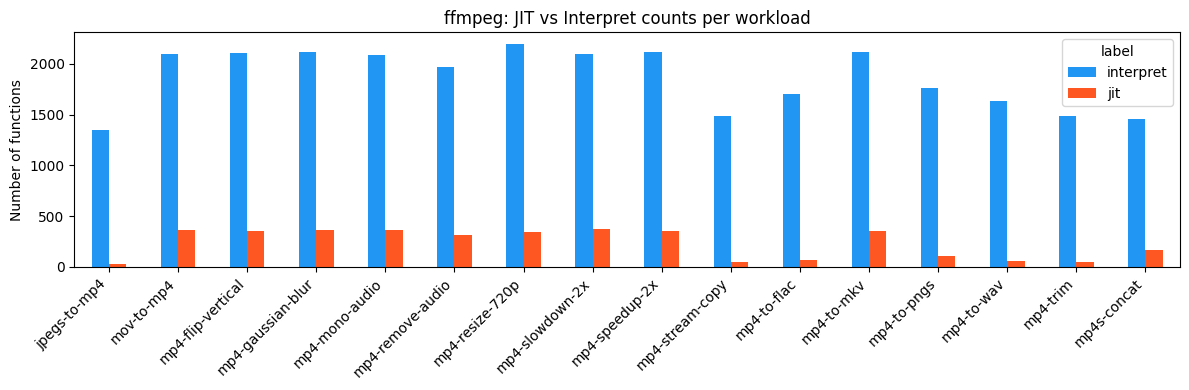

In [6]:
# Per-workload label counts
per_wl = df_all.groupby(['workload', 'label']).size().unstack(fill_value=0)
ax = per_wl.plot(kind='bar', figsize=(12, 4), color=['#2196F3', '#FF5722'])
ax.set_title(f'{BENCHMARK}: JIT vs Interpret counts per workload')
ax.set_ylabel('Number of functions')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Model training

Leave-One-Workload-Out cross-validation to estimate how well the heuristic
generalises to unseen workloads.

In [7]:
X      = df_all[FEATURES].values
y      = df_all['label'].values
groups = df_all['workload'].values

logo = LeaveOneGroupOut()

models = {
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':   DecisionTreeClassifier(max_depth=8, random_state=42),
}

print('Leave-One-Workload-Out CV accuracy:')
for name, clf in models.items():
    scores = cross_val_score(clf, X, y, groups=groups, cv=logo, scoring='accuracy', n_jobs=-1)
    print(f'  {name:20s}  {scores.mean():.4f} ± {scores.std():.4f}')

Leave-One-Workload-Out CV accuracy:
  Random Forest         0.9982 ± 0.0013
  Decision Tree         0.9984 ± 0.0014


In [8]:
# Detailed per-fold report for Random Forest
print('Per-workload accuracy (Random Forest):')
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

fold_results = []
for train_idx, test_idx in logo.split(X, y, groups):
    wl = groups[test_idx][0]
    rf_clf.fit(X[train_idx], y[train_idx])
    preds = rf_clf.predict(X[test_idx])
    acc = (preds == y[test_idx]).mean()
    fold_results.append({'workload': wl, 'accuracy': acc,
                         'n_jit': (y[test_idx] == 'jit').sum(),
                         'n_interp': (y[test_idx] == 'interpret').sum()})

fold_df = pd.DataFrame(fold_results).set_index('workload')
print(fold_df.to_string())

Per-workload accuracy (Random Forest):
                   accuracy  n_jit  n_interp
workload                                    
jpegs-to-mp4       0.998552     32      1349
mov-to-mp4         0.998374    366      2094
mp4-flip-vertical  0.997968    353      2108
mp4-gaussian-blur  0.999196    366      2122
mp4-mono-audio     0.998779    365      2092
mp4-remove-audio   0.999563    317      1970
mp4-resize-720p    0.995681    346      2201
mp4-slowdown-2x    0.999191    371      2102
mp4-speedup-2x     0.997169    351      2122
mp4-stream-copy    1.000000     47      1483
mp4-to-flac        0.998305     71      1699
mp4-to-mkv         0.998383    353      2121
mp4-to-pngs        0.998390    105      1758
mp4-to-wav         0.997636     56      1636
mp4-trim           0.998698     52      1484
mp4s-concat        0.995050    162      1454


## Train final model on all workloads

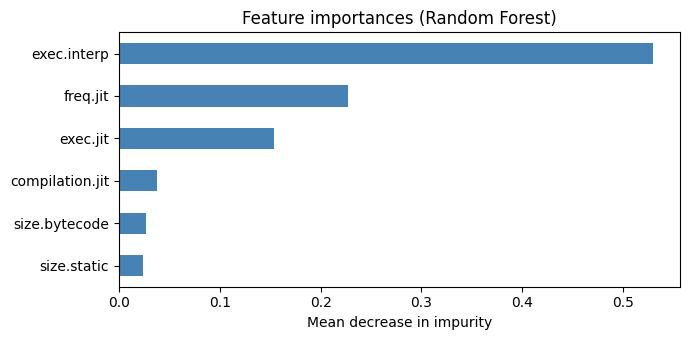

In-sample accuracy: 1.0


In [9]:
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 3.5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importances (Random Forest)')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

print('In-sample accuracy:', (final_model.predict(X) == y).mean())

## Generate `heuristics.json`

Aggregate each function's features (median across workloads), then predict its mode.

In [10]:
def generate_heuristics(benchmark_name, model):
    df_all, _ = load_benchmark_profiles(benchmark_name)

    # Aggregate per function (median across workloads)
    agg = df_all.groupby('id')[FEATURES].median().fillna(0)

    predictions = model.predict(agg[FEATURES].values)

    plan = {'jit': [], 'interpret': [], 'static': [], 'async': [], 'specialize': []}
    for fid, mode in zip(agg.index, predictions):
        plan[mode].append(int(fid))

    return plan, df_all


heuristics, df_used = generate_heuristics(BENCHMARK, final_model)

print(f'heuristics.json summary for {BENCHMARK}:')
for mode, fns in heuristics.items():
    print(f'  {mode:12s}: {len(fns):5d} functions')

heuristics.json summary for ffmpeg:
  jit         :   394 functions
  interpret   :  2799 functions
  static      :     0 functions
  async       :     0 functions
  specialize  :     0 functions


In [11]:
# Compare with oracle-majority-vote for sanity
oracle_vote = (
    df_used.groupby('id')['label']
    .agg(lambda s: s.value_counts().idxmax())
)
pred_series = pd.Series(
    {fid: 'jit' for fid in heuristics['jit']} |
    {fid: 'interpret' for fid in heuristics['interpret']}
)
common = oracle_vote.index.intersection(pred_series.index)
agreement = (oracle_vote[common] == pred_series[common]).mean()
print(f'Agreement with per-function majority-vote oracle: {agreement:.2%}')

Agreement with per-function majority-vote oracle: 99.78%


In [14]:
# Save
out_path = plans_root(BENCHMARK) / 'heuristic.json'
with open(out_path, 'w') as f:
    json.dump(heuristics, f, indent=2)
print(f'Saved → {out_path}')

Saved → /users/khordadi/truejit/plans/ffmpeg/heuristic.json


## Repeat for all benchmarks

In [15]:
BENCHMARKS = ['ffmpeg', 'sqlite']

for bench in BENCHMARKS:
    print(f'\n=== {bench} ===')
    wls = get_workloads(bench)
    if not wls:
        print(f'  No profile.csv files found – run profiling pipeline first.')
        continue

    df_b, wls = load_benchmark_profiles(bench)
    print(f'  Workloads: {len(wls)}, Functions: {df_b["id"].nunique()}')

    Xb = df_b[FEATURES].values
    yb = df_b['label'].values
    gb = df_b['workload'].values

    clf = RandomForestClassifier(n_estimators=100, random_state=42)

    if len(set(gb)) > 1:
        scores = cross_val_score(clf, Xb, yb, groups=gb, cv=LeaveOneGroupOut(),
                                 scoring='accuracy', n_jobs=-1)
        print(f'  LOO accuracy: {scores.mean():.4f} ± {scores.std():.4f}')
    else:
        print('  (single workload – skipping CV)')

    clf.fit(Xb, yb)

    agg = df_b.groupby('id')[FEATURES].median().fillna(0)
    preds = clf.predict(agg[FEATURES].values)
    plan = {'jit': [], 'interpret': [], 'static': [], 'async': [], 'specialize': []}
    for fid, mode in zip(agg.index, preds):
        plan[mode].append(int(fid))

    out_path = plans_root(bench) / 'heuristic.json'
    with open(out_path, 'w') as f:
        json.dump(plan, f, indent=2)
    print(f'  Saved → {out_path}')
    print(f'  JIT: {len(plan["jit"])}, Interpret: {len(plan["interpret"])}')


=== ffmpeg ===
  Workloads: 16, Functions: 3193
  LOO accuracy: 0.9982 ± 0.0013
  Saved → /users/khordadi/truejit/plans/ffmpeg/heuristic.json
  JIT: 394, Interpret: 2799

=== sqlite ===
  No profile.csv files found – run profiling pipeline first.
